EL-GHALI MOHAMED GLCC

In [61]:

import pandas as pd
import torch
import matplotlib.pyplot as plt

In [62]:
# Chargement des données
data=pd.read_csv("../datasets/house_prices_dataset.csv")
X=data["area"]
X_mean=X.mean()
X_std=X.std()
X_norm=(X-X_mean)/X_std
y = data["price"]
y_mean = y.mean()
y_std = y.std()
y_norm = (y-y_mean)/y_std
# Conversion en tenseurs PyTorch
# On utilise reshape/view pour forcer le format en matrice colonne (n_echantillons, 1) attendu par PyTorch
# On précise dtype=torch.double pour éviter les problèmes de précision lors de l'entraînement
X=torch.tensor(X_norm.values.reshape(-1,1), dtype=torch.double)
Y=torch.tensor(y_norm.values, dtype=torch.double).view(-1,1)

In [63]:
# Définition du modèle : une couche linéaire simple (1 entrée -> 1 sortie)
model=torch.nn.Linear(in_features=1, out_features=1, dtype=torch.double)
# Fonction de perte (Erreur Quadratique Moyenne) et Optimiseur (Descente de Gradient Stochastique)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [64]:
# Boucle d'entraînement standard de PyTorch
for epoch in range(1000):
    # 1: On remet les gradients à zéro (sinon ils s'accumulent à chaque itération)
    optimizer.zero_grad()

    # 2: on fait une prédiction avec les poids actuels

    output = model(X)

    # 3: Calcul de l'erreur
    loss = criterion(output, Y)

    # 4: calcul des gradients (rétropropagation)
    loss.backward()

    # 5:Mise à jour des poids (a et b) en fonction des gradients
    optimizer.step()
# On affiche le paramètre trouvé (le poids 'a' de notre régression)
print(model.weight)

Parameter containing:
tensor([[1.0000]], dtype=torch.float64, requires_grad=True)

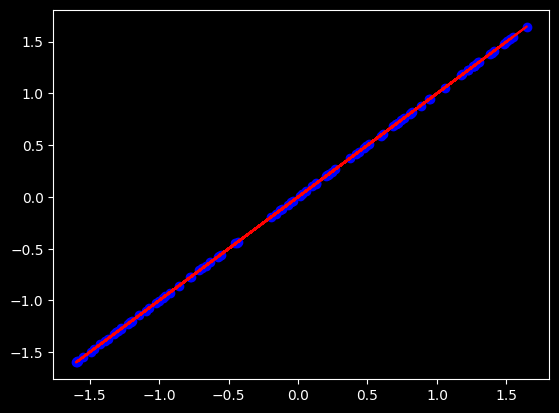

In [65]:
# Visualisation
plt.scatter(X, Y, color="blue")
# On utilise .detach().numpy() pour extraire les prédictions du graphe de calcul
# de PyTorch afin que Matplotlib puisse les lire comme de simples tableaux NumPy
plt.plot(X.detach().numpy(), model(X).detach().numpy(), color="red")
plt.show()